In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(pd.__version__)
print("Assignment 04 environment working")

3.0.3
Assignment 04 environment working


In [4]:
from pathlib import Path

root = Path(".")
for p in root.rglob("*"):
    if p.is_file():
        print(p)

iteration_03_relational_scatter.png
eda.ipynb
iteration_04_bubble_chart.png
iteration_05_small_multiples.png
iteration_08_connected_bubble_scatter.png
iteration_01_wait_time_heatmap.png
iteration_06b_sparse_organs_small_multiples.png
iteration_07_overlaid_distribution_scatter.png
iteration_06a_main_organs_small_multiples.png
iteration_02_long_tail_sorted_heatmap.png


In [5]:
from pathlib import Path

Path(".").resolve()

PosixPath('/Users/justinlocke/Documents/GitHub/dataunlocked-labs/apps/life_flow/assignments/assignment_04_relational/Exploratory')

In [6]:
from pathlib import Path

for p in Path("..").rglob("*.csv"):
    print(p)

../data/raw/Rpt1.3_Donor___Organs_Recovered_by_Donor_Type.csv
../data/raw/Rpt2.2_Waitlist_Additions___Organ_by_List_Year.csv
../data/raw/Rpt1.9_Donor___Organ_by_Living_Donor_Relation_to_Recipient.csv
../data/raw/Rpt3.9_Transplant___Organ_by_Donor_KDPI.csv
../data/raw/Rpt2.6_Waitlist___Organ_by_Primary_Source_of_Payment.csv
../data/raw/Rpt4.2_Multiple_Organ_Transplant___Donor_Type_by_Multiple_Organ.csv
../data/raw/Rpt4.11_Multiple_Organ_Transplant___Donor_Age_by_Multiple_Organ.csv
../data/raw/Rpt2.4_Waitlist___Organ_by_Waiting_List_Status.csv
../data/raw/Rpt4.15_Multiple_Organ_Transplant___Donor_Type_by_Transplant_Center.csv
../data/raw/Rpt4.9_Multiple_Organ_Transplant___Region_of_Center_by_Multiple_Organ.csv
../data/raw/Rpt1.1_Donor___Organ_by_Donor_Type.csv
../data/raw/Rpt3.7_Transplant___Organ_by_Transplant_Center.csv
../data/raw/Rpt3.6_Transplant___Organ_by_VAD_at_Transplant_(HR).csv
../data/raw/Rpt1.8_Donor___Organ_by_Donor_Recovery_Hospital.csv
../data/raw/Rpt4.8_Multiple_Organ_Tr

In [7]:
from pathlib import Path
import pandas as pd

data_path = Path("../data/raw")

inventory = []

for file in data_path.glob("*.csv"):
    try:
        df = pd.read_csv(file)

        inventory.append({
            "file": file.name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "column_names": ", ".join(df.columns[:10])
        })

    except Exception as e:
        inventory.append({
            "file": file.name,
            "rows": "ERROR",
            "columns": "ERROR",
            "column_names": str(e)
        })

inventory_df = pd.DataFrame(inventory)

inventory_df.sort_values("rows", ascending=False).head(20)

,file,rows,columns,column_names
13,Rpt1.8_Donor___Organ_by_Donor_Recovery_Hospita...,2200,9,"Unnamed: 0, Unnamed: 1, All Donors, Kidney, Li..."
40,Rpt3.11_Transplant___Organ_by_Recipient_Diagno...,666,14,"Unnamed: 0, Unnamed: 1, Unnamed: 2, All Organs..."
11,Rpt3.7_Transplant___Organ_by_Transplant_Center...,249,13,"Unnamed: 0, Unnamed: 1, All Organs, Kidney, Li..."
8,Rpt4.15_Multiple_Organ_Transplant___Donor_Type...,134,4,"Unnamed: 0, Unnamed: 1, All Donor Types, Decea..."
42,Rpt3.8_Transplant___Organ_by_Donation_Service_...,57,13,"Unnamed: 0, Unnamed: 1, All Organs, Kidney, Li..."
20,Rpt1.11_Donor___Organ_by_Donation_Service_Area...,56,9,"Unnamed: 0, Unnamed: 1, All Donors, Kidney, Li..."
30,Rpt3.1_Transplant___Organ_by_Transplant_Year.csv,40,17,"Unnamed: 0, Unnamed: 1, All Organs, Kidney, Li..."
26,Rpt3.2_Transplant___Organ_by_Waiting_List_Stat...,38,13,"Unnamed: 0, Unnamed: 1, All Organs, Kidney, Li..."
7,Rpt2.4_Waitlist___Organ_by_Waiting_List_Status...,37,15,"Unnamed: 0, Unnamed: 1, All Organs, Kidney, Li..."
36,Rpt2.3_Waitlist_Additions___Organ_by_List_Year...,33,17,"Unnamed: 0, Unnamed: 1, All Organs, Kidney, Li..."


# Candidate Analytical Directions

## Direction A — Wait-Time Distributions
Potential charts:
- heatmap
- small multiples
- scatter

Key variables:
- organ
- wait bucket
- candidate count

## Direction B — Wait Time vs Outcomes
Potential charts:
- scatterplot
- bubble chart

Key variables:
- wait duration
- transplant/removal/death outcome
- organ

## Direction C — Survival Relationships
Potential charts:
- small multiples
- distribution plots

Key variables:
- organ
- survival milestone
- transplant counts

# Wait-Time Heatmap Iterations

Goal: compare how current waitlist candidates are distributed across OPTN waiting-time buckets for each organ type.

For these first passes, I am using row-wise percentages so each organ can be compared by distribution shape instead of being dominated by kidney volume.

- Iteration 1 keeps organs sorted by total candidate volume.
- Iteration 2 keeps all organs but sorts them by long-tail wait share, which should make short-vs-long wait patterns easier to scan.

In [8]:
# Load the OPTN waitlist waiting-time bucket report.
# This file has wait-time buckets in rows and organ types in columns.
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Save generated iteration images beside this exploratory notebook.
exploratory_output_dir = Path(".")
exploratory_output_dir.mkdir(exist_ok=True)

wait_time_path = Path("../data/raw/Rpt2.1_Waitlist___Organ_by_Waiting_Time.csv")
wait_raw = pd.read_csv(wait_time_path)

print(wait_time_path)
print(f"raw shape: {wait_raw.shape}")
display(wait_raw.head(10))

# Check the column names before cleaning. OPTN exports often include unnamed helper columns.
display(pd.DataFrame({"column": wait_raw.columns, "non_null_count": wait_raw.notna().sum().values}))

../data/raw/Rpt2.1_Waitlist___Organ_by_Waiting_Time.csv
raw shape: (9, 15)


,Unnamed: 0,Unnamed: 1,All Organs,Kidney,Liver,Pancreas,Kidney / Pancreas,Heart,Lung,Heart / Lung,Intestine,VCA - abdominal wall,VCA - head and neck,VCA - upper limb,VCA - uterus
0,All Time,NaN,"109,318","95,036","8,822",837,"2,382","4,054","1,030",30,169,1,2,2,4
1,< 30 Days,NaN,"6,105","4,492",996,42,150,400,227,3,10,0,0,0,1
2,30 to < 90 Days,NaN,"9,325","7,282","1,335",52,208,494,229,4,14,0,0,0,0
3,90 Days to < 6 Months,NaN,"11,604","9,555","1,322",74,301,464,188,2,15,0,0,0,1
4,6 Months to < 1 Year,NaN,"20,439","17,591","1,776",127,497,799,194,6,28,0,1,0,0
5,1 Year to < 2 Years,NaN,"25,742","22,925","1,642",205,652,842,128,2,33,0,0,0,1
6,2 Years to < 3 Years,NaN,"16,379","14,985",753,129,352,443,38,6,23,1,1,2,1
7,3 Years to < 5 Years,NaN,"16,124","15,040",582,92,220,386,18,3,16,0,0,0,0
8,5 or More Years,NaN,"10,381","9,524",493,117,81,264,12,4,33,0,0,0,0


,column,non_null_count
0,Unnamed: 0,9
1,Unnamed: 1,0
2,All Organs,9
3,Kidney,9
4,Liver,9
5,Pancreas,9
6,Kidney / Pancreas,9
7,Heart,9
8,Lung,9
9,Heart / Lung,9


In [9]:
# Clean the export:
# - rename the first unnamed column to a meaningful bucket label
# - drop the blank second unnamed column
# - remove the aggregate organ column and the aggregate wait-time row
# - convert comma-formatted counts to numeric values
wait_clean = (
    wait_raw
    .rename(columns={wait_raw.columns[0]: "wait_time_bucket"})
    .drop(columns=["Unnamed: 1"], errors="ignore")
)

admin_rows = ["All Time"]
admin_columns = ["All Organs"]

wait_clean = wait_clean.loc[~wait_clean["wait_time_bucket"].isin(admin_rows)].copy()
wait_clean = wait_clean.drop(columns=admin_columns, errors="ignore")

count_columns = [col for col in wait_clean.columns if col != "wait_time_bucket"]
wait_clean[count_columns] = wait_clean[count_columns].replace({",": ""}, regex=True).apply(pd.to_numeric)

print(f"clean shape: {wait_clean.shape}")
print("wait-time buckets:")
display(wait_clean["wait_time_bucket"].to_frame())

display(wait_clean.head())
display(wait_clean.dtypes.to_frame("dtype"))

clean shape: (8, 13)
wait-time buckets:


,wait_time_bucket
1,< 30 Days
2,30 to < 90 Days
3,90 Days to < 6 Months
4,6 Months to < 1 Year
5,1 Year to < 2 Years
6,2 Years to < 3 Years
7,3 Years to < 5 Years
8,5 or More Years


,wait_time_bucket,Kidney,Liver,Pancreas,Kidney / Pancreas,Heart,Lung,Heart / Lung,Intestine,VCA - abdominal wall,VCA - head and neck,VCA - upper limb,VCA - uterus
1,< 30 Days,4492,996,42,150,400,227,3,10,0,0,0,1
2,30 to < 90 Days,7282,1335,52,208,494,229,4,14,0,0,0,0
3,90 Days to < 6 Months,9555,1322,74,301,464,188,2,15,0,0,0,1
4,6 Months to < 1 Year,17591,1776,127,497,799,194,6,28,0,1,0,0
5,1 Year to < 2 Years,22925,1642,205,652,842,128,2,33,0,0,0,1


,dtype
wait_time_bucket,str
Kidney,int64
Liver,int64
Pancreas,int64
Kidney / Pancreas,int64
Heart,int64
Lung,int64
Heart / Lung,int64
Intestine,int64
VCA - abdominal wall,int64


In [10]:
# Reshape from wide to long so each row is one organ/bucket/count observation.
wait_long = wait_clean.melt(
    id_vars="wait_time_bucket",
    var_name="organ",
    value_name="candidate_count",
)

# Keep zero-count rows for transparency, but calculate totals so tiny VCA categories are easy to spot.
organ_totals = (
    wait_long
    .groupby("organ", as_index=False)["candidate_count"]
    .sum()
    .rename(columns={"candidate_count": "organ_total"})
    .sort_values("organ_total", ascending=False)
)

print(f"long shape: {wait_long.shape}")
display(wait_long.head(12))

display(organ_totals)

long shape: (96, 3)


,wait_time_bucket,organ,candidate_count
0,< 30 Days,Kidney,4492
1,30 to < 90 Days,Kidney,7282
2,90 Days to < 6 Months,Kidney,9555
3,6 Months to < 1 Year,Kidney,17591
4,1 Year to < 2 Years,Kidney,22925
5,2 Years to < 3 Years,Kidney,14985
6,3 Years to < 5 Years,Kidney,15040
7,5 or More Years,Kidney,9524
8,< 30 Days,Liver,996
9,30 to < 90 Days,Liver,1335


,organ,organ_total
3,Kidney,101394
5,Liver,8899
0,Heart,4092
4,Kidney / Pancreas,2461
6,Lung,1034
7,Pancreas,838
2,Intestine,172
1,Heart / Lung,30
11,VCA - uterus,4
9,VCA - head and neck,2


In [11]:
# Convert counts to percentages within each organ.
# This makes the heatmap compare distribution shape rather than raw waitlist size.
wait_pct_long = wait_long.merge(organ_totals, on="organ", how="left")
wait_pct_long["pct_within_organ"] = wait_pct_long["candidate_count"] / wait_pct_long["organ_total"] * 100

bucket_order = wait_clean["wait_time_bucket"].tolist()
organ_order = organ_totals["organ"].tolist()

wait_pct_heatmap = (
    wait_pct_long
    .pivot(index="organ", columns="wait_time_bucket", values="pct_within_organ")
    .reindex(index=organ_order, columns=bucket_order)
)

# Sanity check: each row should sum to 100% after dropping the aggregate All Time row.
row_sum_check = wait_pct_heatmap.sum(axis=1).round(2).to_frame("row_pct_sum")

display(wait_pct_heatmap.round(1))
display(row_sum_check)

wait_time_bucket,< 30 Days,30 to < 90 Days,90 Days to < 6 Months,6 Months to < 1 Year,1 Year to < 2 Years,2 Years to < 3 Years,3 Years to < 5 Years,5 or More Years
organ,,,,,,,,
Kidney,4.4,7.2,9.4,17.3,22.6,14.8,14.8,9.4
Liver,11.2,15.0,14.9,20.0,18.5,8.5,6.5,5.5
Heart,9.8,12.1,11.3,19.5,20.6,10.8,9.4,6.5
Kidney / Pancreas,6.1,8.5,12.2,20.2,26.5,14.3,8.9,3.3
Lung,22.0,22.1,18.2,18.8,12.4,3.7,1.7,1.2
Pancreas,5.0,6.2,8.8,15.2,24.5,15.4,11.0,14.0
Intestine,5.8,8.1,8.7,16.3,19.2,13.4,9.3,19.2
Heart / Lung,10.0,13.3,6.7,20.0,6.7,20.0,10.0,13.3
VCA - uterus,25.0,0.0,25.0,0.0,25.0,25.0,0.0,0.0


,row_pct_sum
organ,
Kidney,100.0
Liver,100.0
Heart,100.0
Kidney / Pancreas,100.0
Lung,100.0
Pancreas,100.0
Intestine,100.0
Heart / Lung,100.0
VCA - uterus,100.0


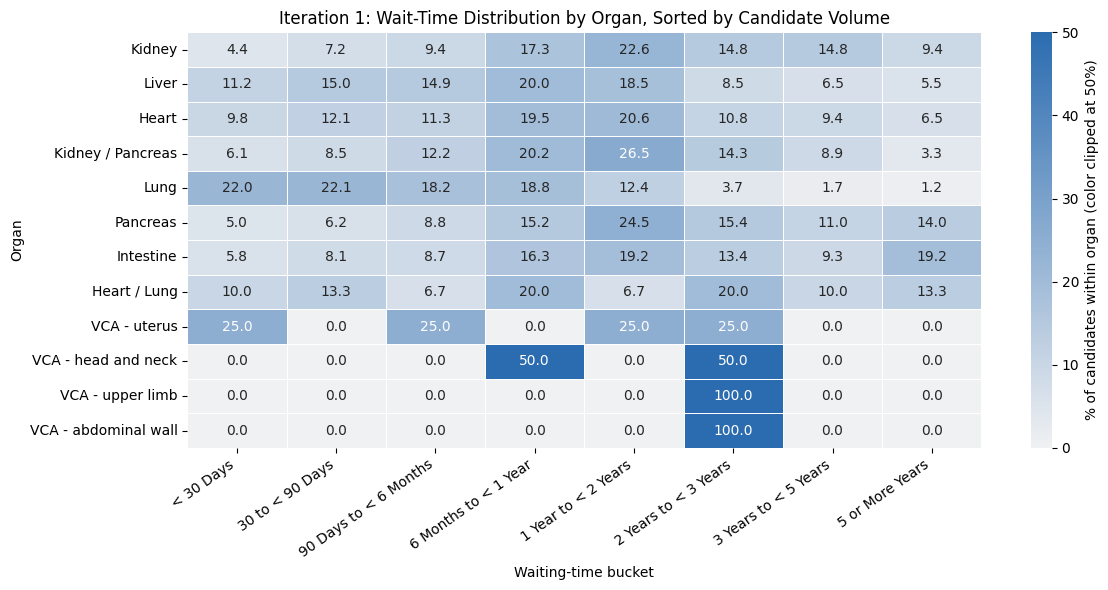

In [12]:
# Iteration 1: all organs, sorted by total candidate volume.
# Use one light-to-dark hue so the color only communicates lower vs higher percentage.
# Swap this hex later if you want to test a different single-hue palette.
heatmap_base_hex = "#2b6cb0"
heatmap_cmap = sns.light_palette(heatmap_base_hex, as_cmap=True)

# Clipping the color scale below 100 keeps one tiny-denominator category from flattening the rest.
# The annotations still show the true percentages.
heatmap_vmax = 50

plt.figure(figsize=(12, 6))
sns.heatmap(
    wait_pct_heatmap,
    annot=True,
    fmt=".1f",
    cmap=heatmap_cmap,
    vmin=0,
    vmax=heatmap_vmax,
    linewidths=0.5,
    cbar_kws={"label": f"% of candidates within organ (color clipped at {heatmap_vmax}%)"},
)

plt.title("Iteration 1: Wait-Time Distribution by Organ, Sorted by Candidate Volume")
plt.xlabel("Waiting-time bucket")
plt.ylabel("Organ")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(exploratory_output_dir / "iteration_01_wait_time_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# Quick diagnostics for the exploratory questions:
# - Long tail: share in buckets of 2+ years
# - Short wait: share in buckets under 90 days
long_tail_buckets = ["2 Years to < 3 Years", "3 Years to < 5 Years", "5 or More Years"]
short_wait_buckets = ["< 30 Days", "30 to < 90 Days"]

distribution_summary = pd.DataFrame({
    "candidate_count": organ_totals.set_index("organ")["organ_total"],
    "pct_under_90_days": wait_pct_heatmap[short_wait_buckets].sum(axis=1),
    "pct_2_or_more_years": wait_pct_heatmap[long_tail_buckets].sum(axis=1),
}).sort_values("pct_2_or_more_years", ascending=False)

# This table helps identify organs with longer tails and organs concentrated in early buckets.
display(distribution_summary.round(1))

,candidate_count,pct_under_90_days,pct_2_or_more_years
organ,,,
VCA - upper limb,2,0.0,100.0
VCA - abdominal wall,1,0.0,100.0
VCA - head and neck,2,0.0,50.0
Heart / Lung,30,23.3,43.3
Intestine,172,14.0,41.9
Pancreas,838,11.2,40.3
Kidney,101394,11.6,39.0
Heart,4092,21.8,26.7
Kidney / Pancreas,2461,14.5,26.5


## Iteration 2: Same Data, Sorted by Long-Tail Share

This keeps all organ categories, including the tiny VCA categories, but changes the row order. Sorting by the share waiting 2 or more years should make long-tail patterns easier to compare without dropping possible signals from small categories.

Important caveat: tiny denominators can create extreme percentages, so the table of candidate counts stays visible next to this view.

,candidate_count,pct_under_90_days,pct_2_or_more_years
organ,,,
VCA - upper limb,2,0.0,100.0
VCA - abdominal wall,1,0.0,100.0
VCA - head and neck,2,0.0,50.0
Heart / Lung,30,23.3,43.3
Intestine,172,14.0,41.9
Pancreas,838,11.2,40.3
Kidney,101394,11.6,39.0
Heart,4092,21.8,26.7
Kidney / Pancreas,2461,14.5,26.5


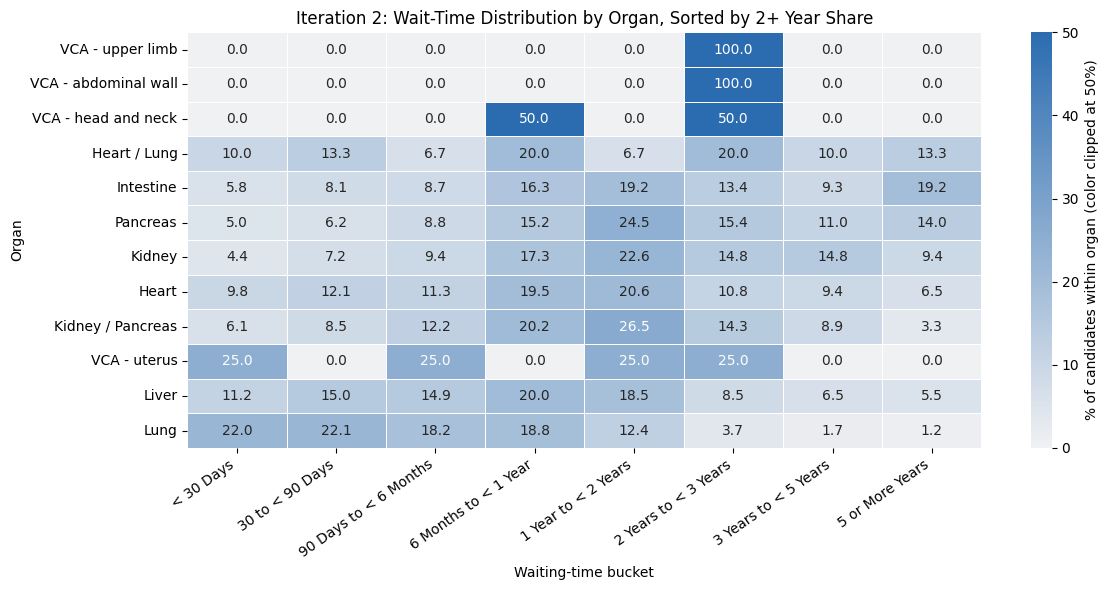

In [14]:
# Iteration 2: all organs again, but sorted by the long-tail share.
# This is the same underlying percentage table as Iteration 1, with no organ categories removed.
iteration_2_order = distribution_summary.sort_values("pct_2_or_more_years", ascending=False).index
iteration_2_heatmap = wait_pct_heatmap.loc[iteration_2_order]

# Keep the denominator visible so tiny categories are not over-interpreted.
display(distribution_summary.loc[iteration_2_order].round(1))

plt.figure(figsize=(12, 6))
sns.heatmap(
    iteration_2_heatmap,
    annot=True,
    fmt=".1f",
    cmap=heatmap_cmap,
    vmin=0,
    vmax=heatmap_vmax,
    linewidths=0.5,
    cbar_kws={"label": f"% of candidates within organ (color clipped at {heatmap_vmax}%)"},
)

plt.title("Iteration 2: Wait-Time Distribution by Organ, Sorted by 2+ Year Share")
plt.xlabel("Waiting-time bucket")
plt.ylabel("Organ")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(exploratory_output_dir / "iteration_02_long_tail_sorted_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Relational EDA Iterations 3-5

These quick iterations connect waitlist burden to transplant activity by organ.

Working proxy choices:
- **Wait burden:** percent of candidates in the `3 Years to < 5 Years` or `5 or More Years` buckets.
- **Outcome / throughput proxy:** 2025 transplants per 100 current waitlist candidates.

Caveat: this is not a patient-level probability. The waitlist count is a current snapshot, while transplant counts are annual activity.

In [15]:
# Build one organ-level dataframe for the relational charts.
# This keeps raw files unchanged and makes every metric visible before plotting.

def clean_count_values(series):
    """Convert OPTN comma-formatted count strings into numeric values."""
    return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False), errors="coerce").fillna(0)

# Current waitlist counts from the explicit All Time row.
# I am using this for bubble sizes and transplant-per-waitlist ratios.
wait_all_time = (
    wait_raw
    .rename(columns={wait_raw.columns[0]: "wait_time_bucket"})
    .query("wait_time_bucket == 'All Time'")
    .drop(columns=["Unnamed: 1", "All Organs"], errors="ignore")
    .melt(id_vars="wait_time_bucket", var_name="organ", value_name="current_waitlist_count")
    .drop(columns="wait_time_bucket")
)
wait_all_time["current_waitlist_count"] = clean_count_values(wait_all_time["current_waitlist_count"])

# 2025 transplant activity by organ from the transplant-by-year report.
transplant_path = Path("../data/raw/Rpt3.1_Transplant___Organ_by_Transplant_Year.csv")
transplant_raw = pd.read_csv(transplant_path)
transplant_clean = transplant_raw.rename(columns={transplant_raw.columns[0]: "transplant_year"})

transplant_2025 = (
    transplant_clean
    .loc[transplant_clean["transplant_year"].astype(str).eq("2025")]
    .drop(columns=["Unnamed: 1", "All Organs"], errors="ignore")
    .melt(id_vars="transplant_year", var_name="organ", value_name="transplants_2025")
    .drop(columns="transplant_year")
)
transplant_2025["transplants_2025"] = clean_count_values(transplant_2025["transplants_2025"])

# Approximate wait score using bucket midpoints in months.
# The open-ended 5+ years bucket is set to 72 months as a conservative placeholder.
bucket_midpoint_months = {
    "< 30 Days": 0.5,
    "30 to < 90 Days": 2,
    "90 Days to < 6 Months": 4.5,
    "6 Months to < 1 Year": 9,
    "1 Year to < 2 Years": 18,
    "2 Years to < 3 Years": 30,
    "3 Years to < 5 Years": 48,
    "5 or More Years": 72,
}

wait_score_long = wait_long.copy()
wait_score_long["bucket_midpoint_months"] = wait_score_long["wait_time_bucket"].map(bucket_midpoint_months)
wait_score_long["weighted_wait_months"] = wait_score_long["candidate_count"] * wait_score_long["bucket_midpoint_months"]

wait_score = (
    wait_score_long
    .groupby("organ", as_index=False)
    .agg(
        bucket_sum_candidate_count=("candidate_count", "sum"),
        weighted_wait_months=("weighted_wait_months", "sum"),
    )
)
wait_score["approx_wait_score_months"] = wait_score["weighted_wait_months"] / wait_score["bucket_sum_candidate_count"]

# Wait-burden percentages reuse the normalized heatmap table from Iterations 1-2.
wait_burden = pd.DataFrame({
    "organ": wait_pct_heatmap.index,
    "pct_waiting_3_plus_years": wait_pct_heatmap[["3 Years to < 5 Years", "5 or More Years"]].sum(axis=1).values,
    "pct_waiting_2_plus_years": wait_pct_heatmap[["2 Years to < 3 Years", "3 Years to < 5 Years", "5 or More Years"]].sum(axis=1).values,
})

relational_metrics = (
    wait_burden
    .merge(wait_score.drop(columns="weighted_wait_months"), on="organ", how="left")
    .merge(wait_all_time, on="organ", how="left")
    .merge(transplant_2025, on="organ", how="left")
)
relational_metrics["transplants_per_100_current_waitlist"] = (
    relational_metrics["transplants_2025"] / relational_metrics["current_waitlist_count"] * 100
)

# Sort by current waitlist size for inspection.
relational_metrics = relational_metrics.sort_values("current_waitlist_count", ascending=False)

print(transplant_path)
print(f"transplant raw shape: {transplant_raw.shape}")
display(transplant_raw.head())

display(relational_metrics.round(1))

../data/raw/Rpt3.1_Transplant___Organ_by_Transplant_Year.csv
transplant raw shape: (40, 17)


,Unnamed: 0,Unnamed: 1,All Organs,Kidney,Liver,Pancreas,Kidney / Pancreas,Heart,Lung,Heart / Lung,Intestine,VCA - abdominal wall,VCA - external male genitalia,VCA - head and neck,VCA - other genitourinary organ,VCA - upper limb,VCA - uterus
0,To Date,NaN,"1,081,410","634,632","239,556","9,633","29,666","102,653","59,806","1,645","3,662",22,2,25,3,38,67
1,2026,NaN,"16,478","9,218","4,355",30,242,"1,458","1,149",7,14,0,0,0,2,0,3
2,2025,NaN,"49,065","27,574","12,344",107,804,"4,587","3,490",61,88,0,0,0,1,0,9
3,2024,NaN,"48,150","27,760","11,458",114,733,"4,572","3,340",64,97,0,0,2,0,1,9
4,2023,NaN,"46,634","27,332","10,659",102,812,"4,545","3,026",54,95,0,0,1,0,0,8


,organ,pct_waiting_3_plus_years,pct_waiting_2_plus_years,bucket_sum_candidate_count,approx_wait_score_months,current_waitlist_count,transplants_2025,transplants_per_100_current_waitlist
0,Kidney,24.2,39.0,101394,24.5,95036,27574,29.0
1,Liver,12.1,20.5,8899,15.8,8822,12344,139.9
2,Heart,15.9,26.7,4092,18.7,4054,4587,113.1
3,Kidney / Pancreas,12.2,26.5,2461,18.3,2382,804,33.8
4,Lung,2.9,6.6,1034,8.1,1030,3490,338.8
5,Pancreas,24.9,40.3,838,26.3,837,107,12.8
6,Intestine,28.5,41.9,172,27.8,169,88,52.1
7,Heart / Lung,23.3,43.3,30,24.0,30,61,203.3
8,VCA - uterus,0.0,25.0,4,13.2,4,9,225.0
9,VCA - head and neck,0.0,50.0,2,19.5,2,0,0.0


## Iteration 3: Relational Scatterplot

Each point is an organ. The x-axis is long-wait burden, and the y-axis is a rough throughput proxy.

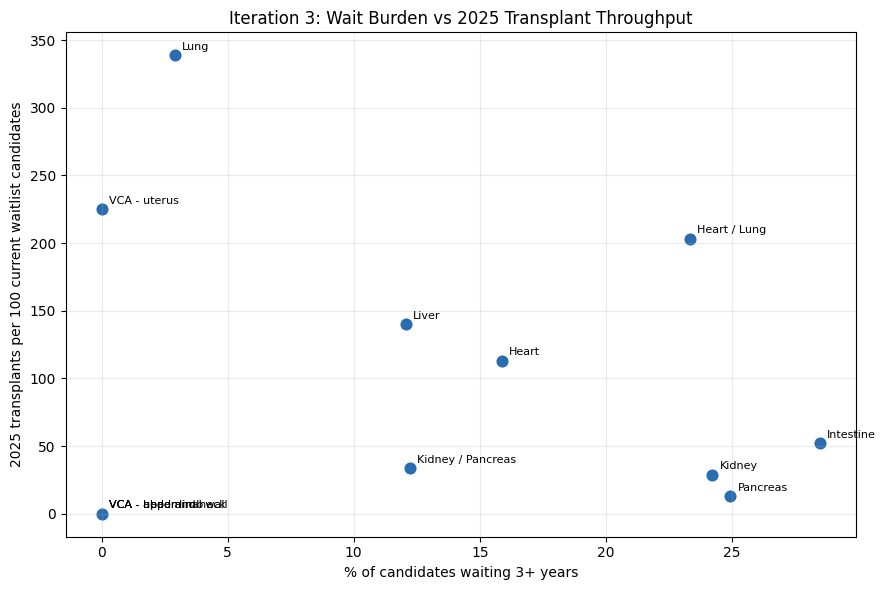

In [16]:
# Iteration 3: simple scatterplot.
# X = long-wait burden; Y = annual transplant activity relative to current waitlist size.
scatter_df = relational_metrics.copy()

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=scatter_df,
    x="pct_waiting_3_plus_years",
    y="transplants_per_100_current_waitlist",
    color=heatmap_base_hex,
    s=90,
    ax=ax,
)

for _, row in scatter_df.iterrows():
    ax.annotate(
        row["organ"],
        (row["pct_waiting_3_plus_years"], row["transplants_per_100_current_waitlist"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Iteration 3: Wait Burden vs 2025 Transplant Throughput")
ax.set_xlabel("% of candidates waiting 3+ years")
ax.set_ylabel("2025 transplants per 100 current waitlist candidates")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(exploratory_output_dir / "iteration_03_relational_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

### Iteration 3 Notes

This view starts to separate organs by backlog shape and transplant throughput. Kidney is expected to stand out as a high-burden, lower-throughput point, while organs such as liver, heart, and lung may sit higher because annual transplant activity is large relative to the current waitlist snapshot.

Usefulness for final slide: promising as a simple relational chart, but the y-axis needs a clear caveat because it mixes a current waitlist snapshot with annual transplant counts.

## Iteration 4: Bubble Chart

Same relationship as Iteration 3, with bubble size showing current waitlist count. The size uses a square-root transform so Kidney does not completely flatten the smaller categories.

,organ,current_waitlist_count,pct_waiting_3_plus_years,transplants_2025,transplants_per_100_current_waitlist,bubble_size
0,Kidney,95036,24.2,27574,29.0,3699.3
1,Liver,8822,12.1,12344,139.9,1127.1
2,Heart,4054,15.9,4587,113.1,764.1
3,Kidney / Pancreas,2382,12.2,804,33.8,585.7
4,Lung,1030,2.9,3490,338.8,385.1
5,Pancreas,837,24.9,107,12.8,347.2
6,Intestine,169,28.5,88,52.1,156.0
7,Heart / Lung,30,23.3,61,203.3,65.7
8,VCA - uterus,4,0.0,9,225.0,24.0
9,VCA - head and neck,2,0.0,0,0.0,17.0


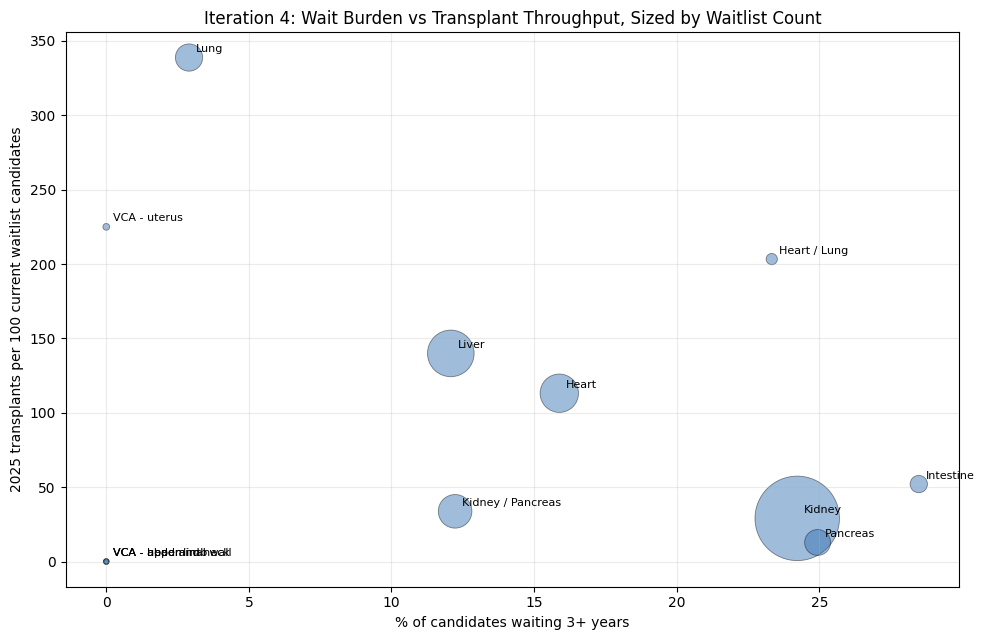

In [17]:
# Iteration 4: bubble chart.
# Bubble area represents current waitlist count, with square-root scaling for readability.
bubble_df = relational_metrics.copy()
bubble_df["bubble_size"] = bubble_df["current_waitlist_count"].pow(0.5) * 12

display(
    bubble_df[
        [
            "organ",
            "current_waitlist_count",
            "pct_waiting_3_plus_years",
            "transplants_2025",
            "transplants_per_100_current_waitlist",
            "bubble_size",
        ]
    ].round(1)
)

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(
    bubble_df["pct_waiting_3_plus_years"],
    bubble_df["transplants_per_100_current_waitlist"],
    s=bubble_df["bubble_size"],
    color=heatmap_base_hex,
    alpha=0.45,
    edgecolor="black",
    linewidth=0.6,
)

for _, row in bubble_df.iterrows():
    ax.annotate(
        row["organ"],
        (row["pct_waiting_3_plus_years"], row["transplants_per_100_current_waitlist"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Iteration 4: Wait Burden vs Transplant Throughput, Sized by Waitlist Count")
ax.set_xlabel("% of candidates waiting 3+ years")
ax.set_ylabel("2025 transplants per 100 current waitlist candidates")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(exploratory_output_dir / "iteration_04_bubble_chart.png", dpi=300, bbox_inches="tight")
plt.show()

### Iteration 4 Notes

The bubble version adds scale: it should make the Kidney backlog visually obvious while still keeping smaller organs in the relationship. This is useful if the final story needs to show both distribution shape and system volume.

Usefulness for final slide: likely stronger than Iteration 3 if the labels remain readable. If the small organs distract, a later version can keep them but reduce label emphasis instead of deleting them.

## Iteration 5: Small Multiples by Organ

This returns to the wait-bucket distributions, but gives every organ its own panel. The goal is to compare distribution shapes without raw Kidney volume dominating the chart.

,organ,wait_time_bucket,candidate_count,pct_within_organ,current_waitlist_count
56,Intestine,< 30 Days,10,5.8,169
57,Intestine,30 to < 90 Days,14,8.1,169
58,Intestine,90 Days to < 6 Months,15,8.7,169
59,Intestine,6 Months to < 1 Year,28,16.3,169
60,Intestine,1 Year to < 2 Years,33,19.2,169
61,Intestine,2 Years to < 3 Years,23,13.4,169
62,Intestine,3 Years to < 5 Years,16,9.3,169
63,Intestine,5 or More Years,33,19.2,169
16,Pancreas,< 30 Days,42,5.0,837
17,Pancreas,30 to < 90 Days,52,6.2,837


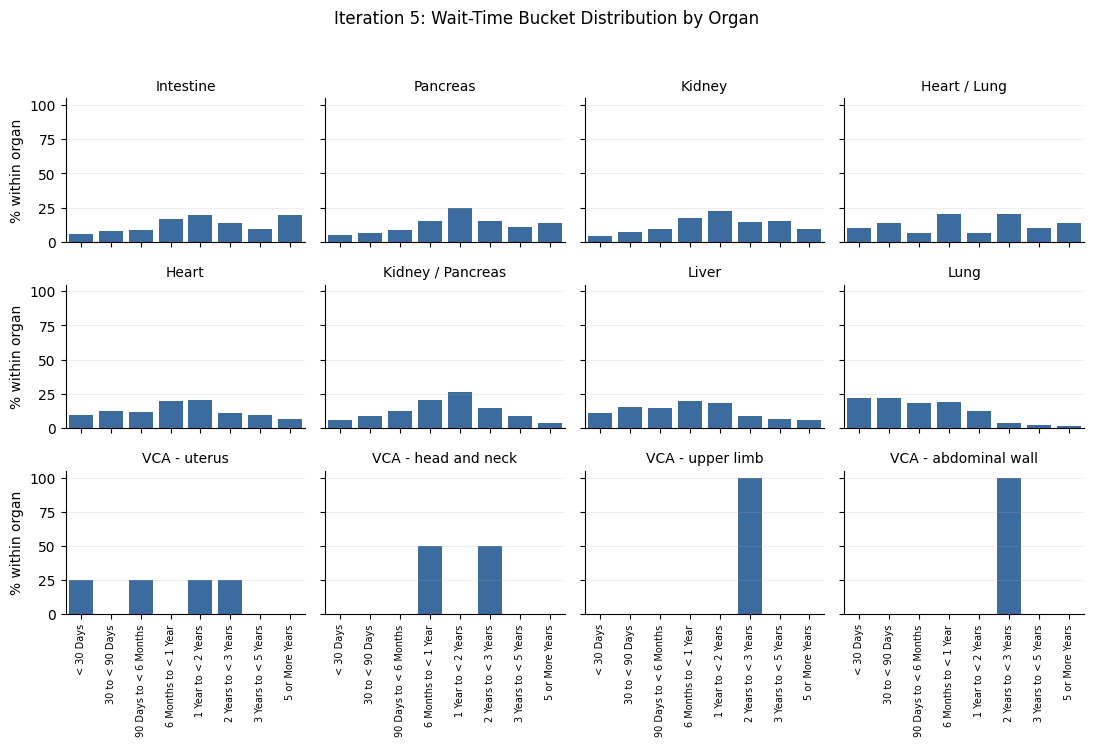

In [18]:
# Iteration 5: small multiples of wait-time distribution by organ.
# These are percentages within organ, so each panel describes distribution shape rather than raw size.
small_multiples_df = wait_pct_long.merge(
    relational_metrics[["organ", "current_waitlist_count", "pct_waiting_3_plus_years"]],
    on="organ",
    how="left",
)

# Sort panels by long-tail burden so similar distribution shapes appear near each other.
small_multiple_order = (
    relational_metrics
    .sort_values("pct_waiting_3_plus_years", ascending=False)["organ"]
    .tolist()
)
small_multiples_df["organ"] = pd.Categorical(
    small_multiples_df["organ"],
    categories=small_multiple_order,
    ordered=True,
)
small_multiples_df["wait_time_bucket"] = pd.Categorical(
    small_multiples_df["wait_time_bucket"],
    categories=bucket_order,
    ordered=True,
)

# Inspect the plotting dataframe before drawing facets.
display(
    small_multiples_df
    .sort_values(["organ", "wait_time_bucket"])
    [["organ", "wait_time_bucket", "candidate_count", "pct_within_organ", "current_waitlist_count"]]
    .head(24)
    .round(1)
)


def draw_wait_bucket_bars(data, **kwargs):
    sns.barplot(
        data=data,
        x="wait_time_bucket",
        y="pct_within_organ",
        order=bucket_order,
        color=heatmap_base_hex,
        errorbar=None,
    )

facet = sns.FacetGrid(
    small_multiples_df.sort_values(["organ", "wait_time_bucket"]),
    col="organ",
    col_wrap=4,
    sharey=True,
    height=2.4,
    aspect=1.15,
)
facet.map_dataframe(draw_wait_bucket_bars)
facet.set_axis_labels("", "% within organ")
facet.set_titles("{col_name}")

for ax in facet.axes.flat:
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.grid(axis="y", alpha=0.2)

facet.fig.suptitle("Iteration 5: Wait-Time Bucket Distribution by Organ", y=1.03)
plt.tight_layout()
facet.fig.savefig(exploratory_output_dir / "iteration_05_small_multiples.png", dpi=300, bbox_inches="tight")
plt.show()

### Iteration 5 Notes

Small multiples should make the distribution shapes easier to compare than the all-in-one heatmap. Kidney can still be read as a long-tail-heavy organ, while organs with more front-loaded waits should show taller bars in the early buckets.

Usefulness for final slide: strong candidate if the assignment story is about distribution differences across organs. It is less relational than Iterations 3-4, but it may be clearer for explaining the wait-time pattern.

## Iteration 6: Small Multiples With Separate Axis Ranges

Iteration 5 is useful, but the tiny-denominator organs make the shared y-axis too tall. A few VCA categories have only 1-4 candidates, so one candidate can create a 25%, 50%, or 100% bar.

This version keeps the data, but separates the display:
- Main organ panels use a tighter 0-30% y-axis.
- Tiny-denominator panels use a separate 0-100% y-axis and should be read as sparse-count patterns, not stable distributions.

Main panels: 7 organs with >= 100 current candidates
Separate sparse panels: 5 organs with < 100 current candidates


,organ,current_waitlist_count,pct_waiting_3_plus_years,panel_group
0,Kidney,95036,24.2,>= 100 candidates
1,Liver,8822,12.1,>= 100 candidates
2,Heart,4054,15.9,>= 100 candidates
3,Kidney / Pancreas,2382,12.2,>= 100 candidates
4,Lung,1030,2.9,>= 100 candidates
5,Pancreas,837,24.9,>= 100 candidates
6,Intestine,169,28.5,>= 100 candidates
7,Heart / Lung,30,23.3,< 100 candidates
8,VCA - uterus,4,0.0,< 100 candidates
9,VCA - head and neck,2,0.0,< 100 candidates


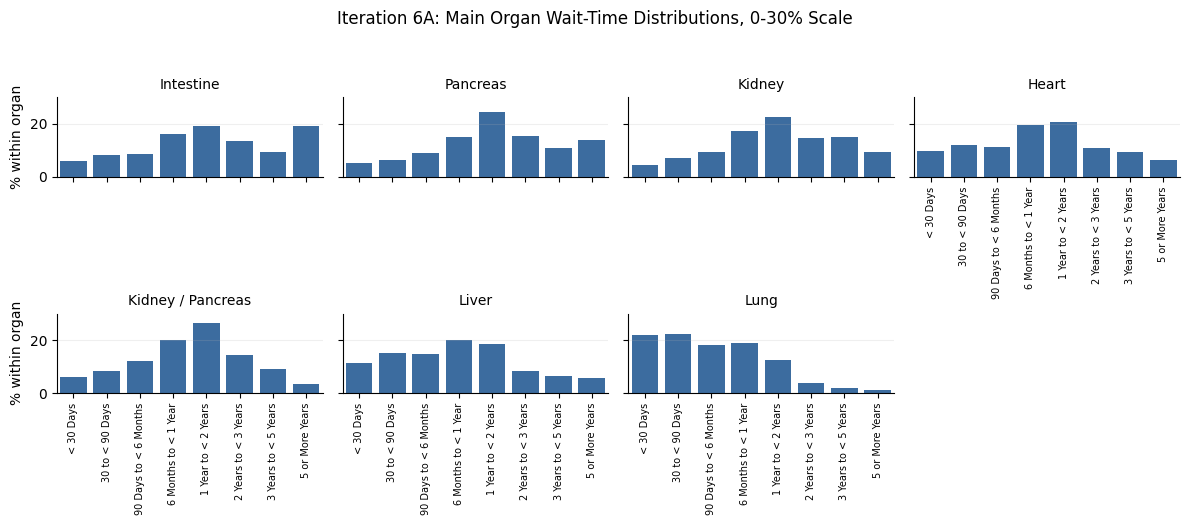

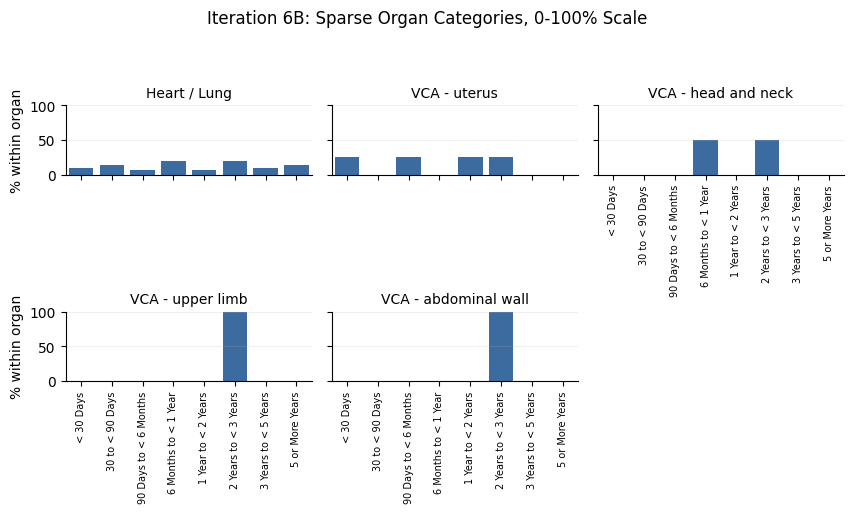

In [19]:
# Iteration 6: improve readability by separating tiny-denominator categories.
# This preserves all data while preventing VCA-style 100% bars from setting the scale.
small_denominator_threshold = 100
iteration_6_df = small_multiples_df.copy()

major_organs = (
    relational_metrics
    .loc[relational_metrics["current_waitlist_count"] >= small_denominator_threshold]
    .sort_values("pct_waiting_3_plus_years", ascending=False)["organ"]
    .tolist()
)
small_denominator_organs = (
    relational_metrics
    .loc[relational_metrics["current_waitlist_count"] < small_denominator_threshold]
    .sort_values("pct_waiting_3_plus_years", ascending=False)["organ"]
    .tolist()
)

print(f"Main panels: {len(major_organs)} organs with >= {small_denominator_threshold} current candidates")
print(f"Separate sparse panels: {len(small_denominator_organs)} organs with < {small_denominator_threshold} current candidates")

display(
    relational_metrics
    .assign(
        panel_group=lambda df: df["current_waitlist_count"].apply(
            lambda count: f"< {small_denominator_threshold} candidates"
            if count < small_denominator_threshold
            else f">= {small_denominator_threshold} candidates"
        )
    )
    [["organ", "current_waitlist_count", "pct_waiting_3_plus_years", "panel_group"]]
    .round(1)
)


def draw_iteration_6_bars(data, **kwargs):
    sns.barplot(
        data=data,
        x="wait_time_bucket",
        y="pct_within_organ",
        order=bucket_order,
        color=heatmap_base_hex,
        errorbar=None,
    )

# Main organ view: tighter scale makes the 5-30% distribution differences legible.
main_plot_df = iteration_6_df.loc[iteration_6_df["organ"].isin(major_organs)].copy()
main_plot_df["organ"] = pd.Categorical(main_plot_df["organ"].astype(str), categories=major_organs, ordered=True)

main_facet = sns.FacetGrid(
    main_plot_df.sort_values(["organ", "wait_time_bucket"]),
    col="organ",
    col_wrap=4,
    sharey=True,
    height=2.5,
    aspect=1.2,
)
main_facet.map_dataframe(draw_iteration_6_bars)
main_facet.set_axis_labels("", "% within organ")
main_facet.set_titles("{col_name}")
main_facet.set(ylim=(0, 30))

for ax in main_facet.axes.flat:
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.grid(axis="y", alpha=0.2)

main_facet.fig.suptitle("Iteration 6A: Main Organ Wait-Time Distributions, 0-30% Scale", y=1.04)
plt.tight_layout()
main_facet.fig.savefig(exploratory_output_dir / "iteration_06a_main_organs_small_multiples.png", dpi=300, bbox_inches="tight")
plt.show()

# Sparse/tiny-denominator view: separate scale keeps these visible without distorting the main chart.
sparse_plot_df = iteration_6_df.loc[iteration_6_df["organ"].isin(small_denominator_organs)].copy()
sparse_plot_df["organ"] = pd.Categorical(sparse_plot_df["organ"].astype(str), categories=small_denominator_organs, ordered=True)

sparse_facet = sns.FacetGrid(
    sparse_plot_df.sort_values(["organ", "wait_time_bucket"]),
    col="organ",
    col_wrap=3,
    sharey=True,
    height=2.4,
    aspect=1.2,
)
sparse_facet.map_dataframe(draw_iteration_6_bars)
sparse_facet.set_axis_labels("", "% within organ")
sparse_facet.set_titles("{col_name}")
sparse_facet.set(ylim=(0, 100))

for ax in sparse_facet.axes.flat:
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.grid(axis="y", alpha=0.2)

sparse_facet.fig.suptitle("Iteration 6B: Sparse Organ Categories, 0-100% Scale", y=1.06)
plt.tight_layout()
sparse_facet.fig.savefig(exploratory_output_dir / "iteration_06b_sparse_organs_small_multiples.png", dpi=300, bbox_inches="tight")
plt.show()

### Iteration 6 Notes

This is likely more readable than Iteration 5 for the main organ comparison. The 0-30% scale should make the first two rows easier to scan because the meaningful differences are mostly in that range.

The sparse-category chart keeps VCA and Heart/Lung visible without letting their tiny denominators control the axis. For the final slide, Iteration 6A is probably the cleaner candidate; Iteration 6B is useful as an appendix-style caveat if we need to explain why those categories are not emphasized.

## Iteration 7: Single Overlaid Distribution Scatter

This condenses the small multiples into one chart. Each observation is one `organ + wait-time bucket` pair.

Encoding:
- x-axis = ordered wait-time bucket
- y-axis = percent within organ
- color = organ
- bubble area = 2025 transplant count for that organ

This does not mix typologies as long as the x-axis is the full ordered bucket scale. It would be too narrow if the x-axis were only `"< 30 Days"`.

,organ,wait_time_bucket,pct_within_organ,candidate_count,transplants_2025,bubble_area
32,Heart,< 30 Days,9.8,400,4587,137.3
33,Heart,30 to < 90 Days,12.1,494,4587,137.3
34,Heart,90 Days to < 6 Months,11.3,464,4587,137.3
35,Heart,6 Months to < 1 Year,19.5,799,4587,137.3
36,Heart,1 Year to < 2 Years,20.6,842,4587,137.3
...,...,...,...,...,...,...
91,VCA - uterus,6 Months to < 1 Year,0.0,0,9,35.2
92,VCA - uterus,1 Year to < 2 Years,25.0,1,9,35.2
93,VCA - uterus,2 Years to < 3 Years,25.0,1,9,35.2
94,VCA - uterus,3 Years to < 5 Years,0.0,0,9,35.2


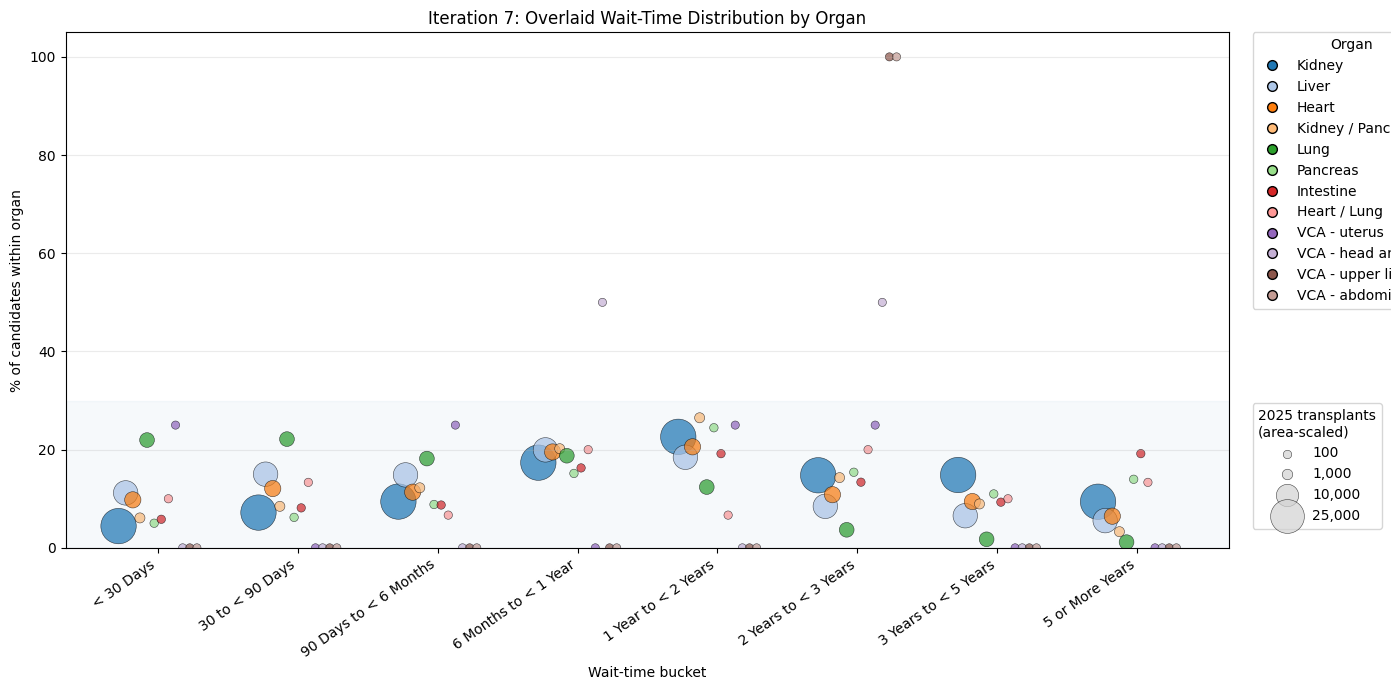

In [20]:
# Iteration 7: one overlaid scatter of the same wait-bucket distributions.
# Matplotlib's `s` parameter is marker area, so the size encoding below is area-based.
from matplotlib.lines import Line2D

iteration_7_df = wait_pct_long.merge(
    relational_metrics[["organ", "current_waitlist_count", "transplants_2025"]],
    on="organ",
    how="left",
)
iteration_7_df["wait_time_bucket"] = pd.Categorical(
    iteration_7_df["wait_time_bucket"],
    categories=bucket_order,
    ordered=True,
)

# Keep bubble areas readable while preserving larger/smaller transplant-volume ordering.
# The area is scaled linearly from transplant counts, not by marker diameter.
min_bubble_area = 35
max_bubble_area = 650
max_transplants = iteration_7_df["transplants_2025"].max()
iteration_7_df["bubble_area"] = (
    min_bubble_area
    + (iteration_7_df["transplants_2025"] / max_transplants) * (max_bubble_area - min_bubble_area)
)

# Add small deterministic jitter within each bucket so overlapping organs remain visible.
iteration_7_organ_order = relational_metrics.sort_values("current_waitlist_count", ascending=False)["organ"].tolist()
bucket_to_x = {bucket: idx for idx, bucket in enumerate(bucket_order)}
if len(iteration_7_organ_order) > 1:
    organ_offsets = {
        organ: -0.28 + i * (0.56 / (len(iteration_7_organ_order) - 1))
        for i, organ in enumerate(iteration_7_organ_order)
    }
else:
    organ_offsets = {iteration_7_organ_order[0]: 0}

iteration_7_df["x_position"] = (
    iteration_7_df["wait_time_bucket"].map(bucket_to_x).astype(float)
    + iteration_7_df["organ"].map(organ_offsets)
)

# Inspect the exact observations that feed the scatter.
display(
    iteration_7_df
    .sort_values(["organ", "wait_time_bucket"])
    [["organ", "wait_time_bucket", "pct_within_organ", "candidate_count", "transplants_2025", "bubble_area"]]
    .round(1)
)

fig, ax = plt.subplots(figsize=(14, 7))
palette = dict(zip(iteration_7_organ_order, sns.color_palette("tab20", n_colors=len(iteration_7_organ_order))))

for organ in iteration_7_organ_order:
    organ_df = iteration_7_df.loc[iteration_7_df["organ"] == organ]
    ax.scatter(
        organ_df["x_position"],
        organ_df["pct_within_organ"],
        s=organ_df["bubble_area"],
        color=palette[organ],
        alpha=0.72,
        edgecolor="black",
        linewidth=0.4,
        label=organ,
    )

ax.set_title("Iteration 7: Overlaid Wait-Time Distribution by Organ")
ax.set_xlabel("Wait-time bucket")
ax.set_ylabel("% of candidates within organ")
ax.set_xticks(range(len(bucket_order)))
ax.set_xticklabels(bucket_order, rotation=35, ha="right")
ax.set_ylim(0, 105)
ax.axhspan(0, 30, color=heatmap_base_hex, alpha=0.04, label="0-30% main comparison range")
ax.grid(axis="y", alpha=0.25)

# Separate legends keep organ color and bubble area easier to parse.
color_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="white",
        markerfacecolor=palette[organ],
        markeredgecolor="black",
        markersize=7,
        label=organ,
    )
    for organ in iteration_7_organ_order
]
organ_legend = ax.legend(
    handles=color_handles,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    title="Organ",
)
ax.add_artist(organ_legend)

size_reference_counts = [100, 1_000, 10_000, 25_000]
size_reference_counts = [count for count in size_reference_counts if count <= max_transplants]
size_handles = [
    ax.scatter(
        [],
        [],
        s=min_bubble_area + (count / max_transplants) * (max_bubble_area - min_bubble_area),
        color="lightgray",
        alpha=0.72,
        edgecolor="black",
        linewidth=0.4,
        label=f"{count:,}",
    )
    for count in size_reference_counts
]
ax.legend(
    handles=size_handles,
    bbox_to_anchor=(1.02, 0.28),
    loc="upper left",
    borderaxespad=0,
    title="2025 transplants\n(area-scaled)",
)

plt.tight_layout()
plt.savefig(exploratory_output_dir / "iteration_07_overlaid_distribution_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

### Iteration 7 Notes

This is a useful compression of the small multiples because it keeps all organs and all wait buckets in one view. The x-axis remains an ordered categorical time scale, so the chart is still comparing wait distributions rather than mixing unrelated types.

Tradeoff: this is denser than Iteration 6. It may work well as an exploratory chart, but for a final slide the small multiples may still explain the pattern more clearly. Bubble area helps show transplant volume, though Kidney will naturally dominate because its 2025 transplant count is much larger than most organs.

## Iteration 8: Connected Bubble Scatter

This builds directly on Iteration 7. Each organ still has one bubble per wait-time bucket, but a thin same-color line connects the organ's observations across the ordered buckets.

The line should make each organ's distribution path easier to follow without turning the chart into a heavy line plot.

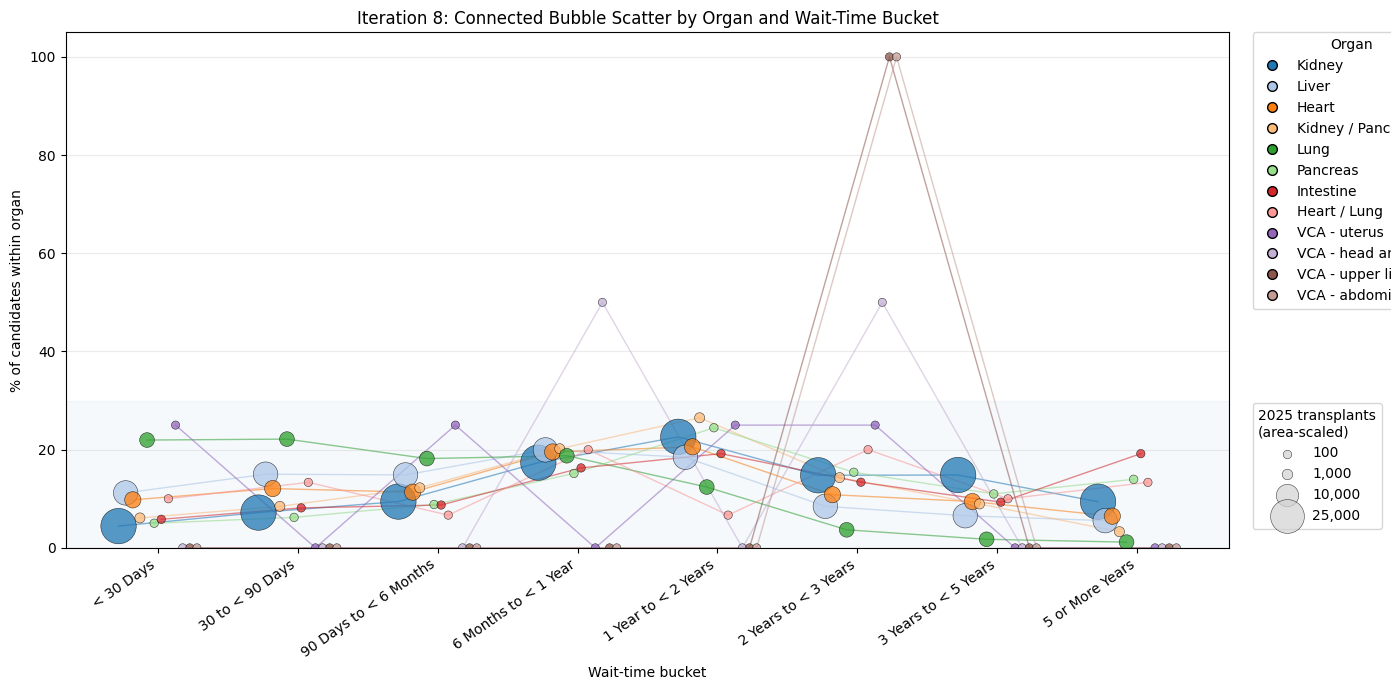

In [21]:
# Iteration 8: connected version of Iteration 7.
# Lines use the same color as each organ's bubbles and stay thin to avoid overpowering the points.
fig, ax = plt.subplots(figsize=(14, 7))

for organ in iteration_7_organ_order:
    organ_df = (
        iteration_7_df
        .loc[iteration_7_df["organ"] == organ]
        .sort_values("wait_time_bucket")
    )

    ax.plot(
        organ_df["x_position"],
        organ_df["pct_within_organ"],
        color=palette[organ],
        linewidth=1.0,
        alpha=0.55,
        zorder=1,
    )

    ax.scatter(
        organ_df["x_position"],
        organ_df["pct_within_organ"],
        s=organ_df["bubble_area"],
        color=palette[organ],
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4,
        zorder=2,
    )

ax.set_title("Iteration 8: Connected Bubble Scatter by Organ and Wait-Time Bucket")
ax.set_xlabel("Wait-time bucket")
ax.set_ylabel("% of candidates within organ")
ax.set_xticks(range(len(bucket_order)))
ax.set_xticklabels(bucket_order, rotation=35, ha="right")
ax.set_ylim(0, 105)
ax.axhspan(0, 30, color=heatmap_base_hex, alpha=0.04)
ax.grid(axis="y", alpha=0.25)

organ_legend = ax.legend(
    handles=color_handles,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    title="Organ",
)
ax.add_artist(organ_legend)

ax.legend(
    handles=size_handles,
    bbox_to_anchor=(1.02, 0.28),
    loc="upper left",
    borderaxespad=0,
    title="2025 transplants\n(area-scaled)",
)

plt.tight_layout()
plt.savefig(exploratory_output_dir / "iteration_08_connected_bubble_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

### Iteration 8 Notes

The connecting lines should help trace each organ across the wait-time buckets, especially where bubbles overlap. If the chart feels too busy, the next adjustment would be to use Iteration 8 only for the main/high-volume organs and keep sparse categories separate as in Iteration 6.